In [1]:
import torch
import torchvision
from torchvision.transforms import v2
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
device=torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [2]:
train_dataset = torchvision.datasets.CIFAR10(root='/data',
                                             train=True,
                                             download=True,
                                             transform=v2.Compose([v2.ToImage(),
                                                                   v2.ToDtype(torch.float32,scale=True),
                                                                   v2.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])]))
test_dataset = torchvision.datasets.CIFAR10(root='/data',
                                             train=False,
                                             download=True,
                                             transform=v2.Compose([v2.ToImage(),
                                                                   v2.ToDtype(torch.float32,scale=True),
                                                                   v2.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])]))


In [3]:
tasks=[[0,1],[2],[3],[4],[5],[6],[7],[8],[9]]

In [4]:
from torch.utils.data import Subset
task_train_datasets=[]

for classes in tasks:
  indices=[i for i ,(_,label) in enumerate(train_dataset) if label in classes]
  task_train_datasets.append(Subset(train_dataset,indices))

task_test_datasets=[]
for classes in tasks:
  indices=[i for i, (_,label) in enumerate(test_dataset) if label in classes]
  task_test_datasets.append(Subset(test_dataset,indices))

In [5]:
task1_loader=DataLoader(task_train_datasets[0],batch_size=10,shuffle=True)
test1_loader=DataLoader(task_test_datasets[0],batch_size=10,shuffle=True)

In [6]:
task_train_datasets[0][0][0].shape #torch.Size([3, 32, 32]) too small for 7*7

torch.Size([3, 32, 32])

In [7]:
from functools import partial
DefaultConv2d=partial(nn.Conv2d,kernel_size=3,stride=1,padding=1)
class ImageNet(nn.Module):

  def __init__(self):
    super().__init__()
    self.conv_layer=nn.Sequential(
        DefaultConv2d(3,32),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        DefaultConv2d(32,64),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        DefaultConv2d(64,128),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        DefaultConv2d(128,256),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        )
    self.linear_layer=nn.Sequential(
        nn.LazyLinear(256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(256,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(64,10),
        nn.BatchNorm1d(10),
        nn.ReLU(),
        nn.Dropout(0.5),

        nn.Linear(10,2),
      )
  def forward(self,x):
    x=self.conv_layer(x)
    x=torch.flatten(x,1)
    x=self.linear_layer(x)
    return x

In [8]:
net=ImageNet().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(net.parameters(),lr=0.001,momentum=0.9)

In [9]:
result_loss=0
net.train()
for epoch in range(10):
  for batch,data in enumerate(task1_loader):
    images,labels=data
    images=images.to(device)
    labels=labels.to(device)
    output=net(images)
    optimizer.zero_grad()
    loss=criterion(output,labels)
    loss.backward()
    optimizer.step()

    result_loss+=loss.item()

    if batch%200==199:
      print(f"Epoch:{epoch+1} , Batch:{batch+1} , Loss:{result_loss/200:.4f}")
      result_loss=0

Epoch:1 , Batch:200 , Loss:0.6900
Epoch:1 , Batch:400 , Loss:0.5767
Epoch:1 , Batch:600 , Loss:0.5240
Epoch:1 , Batch:800 , Loss:0.4688
Epoch:1 , Batch:1000 , Loss:0.4227
Epoch:2 , Batch:200 , Loss:0.3875
Epoch:2 , Batch:400 , Loss:0.3859
Epoch:2 , Batch:600 , Loss:0.3777
Epoch:2 , Batch:800 , Loss:0.3817
Epoch:2 , Batch:1000 , Loss:0.3477
Epoch:3 , Batch:200 , Loss:0.3301
Epoch:3 , Batch:400 , Loss:0.3257
Epoch:3 , Batch:600 , Loss:0.3060
Epoch:3 , Batch:800 , Loss:0.2911
Epoch:3 , Batch:1000 , Loss:0.3248
Epoch:4 , Batch:200 , Loss:0.2832
Epoch:4 , Batch:400 , Loss:0.2657
Epoch:4 , Batch:600 , Loss:0.2541
Epoch:4 , Batch:800 , Loss:0.2347
Epoch:4 , Batch:1000 , Loss:0.2905
Epoch:5 , Batch:200 , Loss:0.2390
Epoch:5 , Batch:400 , Loss:0.2784
Epoch:5 , Batch:600 , Loss:0.2250
Epoch:5 , Batch:800 , Loss:0.2631
Epoch:5 , Batch:1000 , Loss:0.2206
Epoch:6 , Batch:200 , Loss:0.2409
Epoch:6 , Batch:400 , Loss:0.1969
Epoch:6 , Batch:600 , Loss:0.2090
Epoch:6 , Batch:800 , Loss:0.2181
Epoch:6 ,

In [10]:
correct_label=0
total_label=0

net.eval()
with torch.no_grad():
  for image,label in test1_loader:
    image=image.to(device)
    label=label.to(device)
    output=net(image)
    _,predicted=torch.max(output,1)
    total_label+=label.size(0)
    correct_label+=(predicted==label).sum().item()

In [11]:
print(f"Accuracy is {100*correct_label/total_label:.2f}%")

Accuracy is 96.70%


In [12]:
task2_loader=DataLoader(task_train_datasets[1],batch_size=10,shuffle=True)
test2_loader=DataLoader(task_test_datasets[1],batch_size=10,shuffle=True)

In [13]:
old_fc=net.linear_layer[-1]
new_fc=nn.Linear(10,3)

with torch.no_grad():
  new_fc.weight[:2]=old_fc.weight[:]
  new_fc.bias[:2]=old_fc.bias[:]
net.linear_layer[-1]=new_fc

In [14]:
new_fc.state_dict()

OrderedDict([('weight',
              tensor([[-0.3784,  0.5193,  0.4872,  0.4593,  0.4246,  0.4390, -0.3456, -0.3739,
                       -0.2465, -0.4150],
                      [ 0.4977, -0.3728, -0.4267, -0.4655, -0.4490, -0.4042,  0.5498,  0.4740,
                        0.6426,  0.4058],
                      [-0.0056, -0.0900,  0.0692, -0.2440,  0.1088,  0.1190, -0.1422,  0.2257,
                        0.0975, -0.3151]])),
             ('bias', tensor([-0.0275, -0.0635,  0.0588]))])

In [15]:
old_fc.state_dict()

OrderedDict([('weight',
              tensor([[-0.3784,  0.5193,  0.4872,  0.4593,  0.4246,  0.4390, -0.3456, -0.3739,
                       -0.2465, -0.4150],
                      [ 0.4977, -0.3728, -0.4267, -0.4655, -0.4490, -0.4042,  0.5498,  0.4740,
                        0.6426,  0.4058]], device='cuda:0')),
             ('bias', tensor([-0.0275, -0.0635], device='cuda:0'))])

In [16]:
net.linear_layer[-1].state_dict()

OrderedDict([('weight',
              tensor([[-0.3784,  0.5193,  0.4872,  0.4593,  0.4246,  0.4390, -0.3456, -0.3739,
                       -0.2465, -0.4150],
                      [ 0.4977, -0.3728, -0.4267, -0.4655, -0.4490, -0.4042,  0.5498,  0.4740,
                        0.6426,  0.4058],
                      [-0.0056, -0.0900,  0.0692, -0.2440,  0.1088,  0.1190, -0.1422,  0.2257,
                        0.0975, -0.3151]])),
             ('bias', tensor([-0.0275, -0.0635,  0.0588]))])

In [17]:
new_optimizer=torch.optim.Adam(net.parameters(),lr=0.001)

In [18]:
net.to(device)
net.train()
result_loss=0

for epoch in range(10):
  for i, (images, labels) in enumerate(task2_loader):
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()

    output=net(images)
    loss=criterion(output,labels)
    loss.backward()
    optimizer.step()
    result_loss+=loss.item()

    if i %250==249:
      print(f"Epoch:{(epoch+1):2d}, Batch:{(i+1):2d}, Loss: {result_loss/250:.4f}")
      result_loss=0

Epoch: 1, Batch:250, Loss: 2.1406
Epoch: 1, Batch:500, Loss: 1.1799
Epoch: 2, Batch:250, Loss: 1.0147
Epoch: 2, Batch:500, Loss: 0.9913
Epoch: 3, Batch:250, Loss: 0.9854
Epoch: 3, Batch:500, Loss: 0.9808
Epoch: 4, Batch:250, Loss: 0.9766
Epoch: 4, Batch:500, Loss: 0.9773
Epoch: 5, Batch:250, Loss: 0.9756
Epoch: 5, Batch:500, Loss: 0.9707
Epoch: 6, Batch:250, Loss: 0.9745
Epoch: 6, Batch:500, Loss: 0.9700
Epoch: 7, Batch:250, Loss: 0.9632
Epoch: 7, Batch:500, Loss: 0.9660
Epoch: 8, Batch:250, Loss: 0.9640
Epoch: 8, Batch:500, Loss: 0.9679
Epoch: 9, Batch:250, Loss: 0.9656
Epoch: 9, Batch:500, Loss: 0.9681
Epoch:10, Batch:250, Loss: 0.9623
Epoch:10, Batch:500, Loss: 0.9641


In [19]:
#only on 3rd class now
correct_label=0
total_label=0
net.eval()
with torch.no_grad():
  for image, label in test2_loader:
    image=image.to(device)
    label=label.to(device)
    output=net(images)
    _,predicted=torch.max(output,1)

    total_label+=label.size(0)
    correct_label+=(predicted==label).sum().item()


In [20]:
accuracy=100*(correct_label/total_label)
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 90.00%


In [21]:
from torch.utils.data import ConcatDataset

# testing dataset on previous classes
combined_dataset=ConcatDataset([
    task1_loader.dataset,task2_loader.dataset
])

combined_task=DataLoader(combined_dataset,batch_size=64,shuffle=True)

In [22]:
all_labels=[]
correct_labels=[]
net.eval()
with torch.no_grad():
  for images, labels in combined_task:
    images=images.to(device)
    labels=labels.to(device)

    output=net(images)
    _,predicted=torch.max(output,1)
    all_labels.extend(labels.to('cpu').numpy())
    correct_labels.extend(predicted.to('cpu').numpy())

In [23]:
classes = ('plane', 'car', 'bird',)

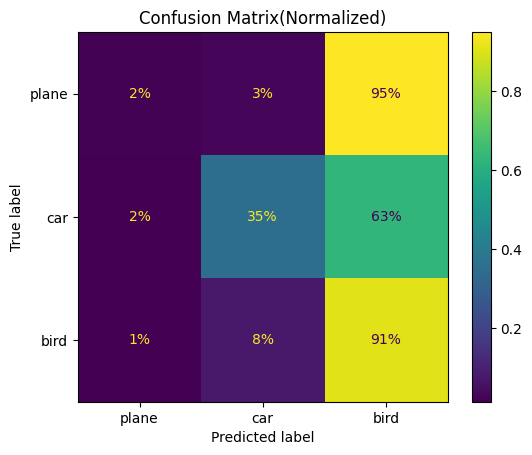

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    correct_labels,
    display_labels=classes,
    normalize='true',
    values_format='.0%'
)
plt.title("Confusion Matrix(Normalized)")
plt.show()